In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [3]:
df = pd.read_csv("./placement.csv")
df.sample(5)

,cgpa,placement_exam_marks,placed
403,6.71,83.0,0
954,8.00,39.0,1
365,7.07,25.0,0
753,6.87,42.0,0
130,5.91,53.0,0


In [5]:
col2 = df["placement_exam_marks"]

In [12]:
import warnings
warnings.filterwarnings("ignore")
def dist2Cart(c2):
    plt.figure(figsize=(16, 5))
    plt.subplot(1, 2, 2)
    sns.distplot(c2)
    plt.show()

In [14]:
def dist2Chart(c2):
    plt.figure(figsize=(16, 5))
    plt.subplot(1, 2, 2)
    sns.histplot(c2)
    plt.show()

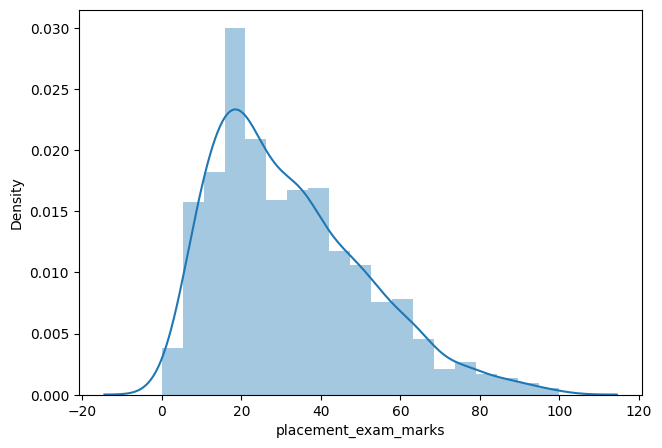

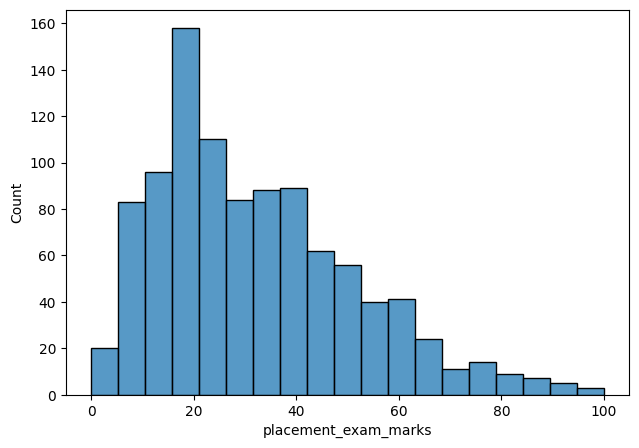

In [16]:
dist2Cart(col2)
dist2Chart(col2)

<Axes: ylabel='placement_exam_marks'>

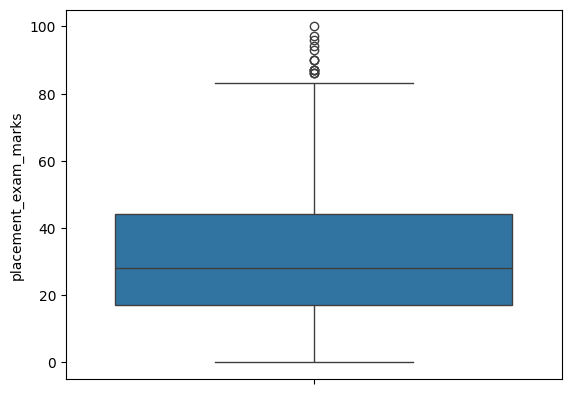

In [17]:
sns.boxplot(col2)

In [19]:
q1 = col2.quantile(0.25)
q2 = col2.quantile(0.50)
q3 = col2.quantile(0.75)
print("Min = 0.0")
print("percentile 25% = ", q1)
print("percentile 50% = ", q2)
print("percentile 75% = ", q3)
print("Max = 100.0")

Min = 0.0
percentile 25% =  17.0
percentile 50% =  28.0
percentile 75% =  44.0
Max = 100.0


In [22]:
iqr = q3 - q1
float(iqr)

27.0

In [23]:
iqrVal = 1.5 * iqr
lower_limit = q1 - iqrVal
upper_limit = q3 + iqrVal
print("Lower limit: ", lower_limit)
print("Upper Limit: ", upper_limit)

Lower limit:  -23.5
Upper Limit:  84.5


In [24]:
df[col2 < lower_limit].count()

cgpa                    0
placement_exam_marks    0
placed                  0
dtype: int64

In [26]:
df[col2 > upper_limit].count()

cgpa                    15
placement_exam_marks    15
placed                  15
dtype: int64

In [27]:
df[col2 > upper_limit]

,cgpa,placement_exam_marks,placed
9,7.75,94.0,1
40,6.60,86.0,1
61,7.51,86.0,0
134,6.33,93.0,0
162,7.80,90.0,0
283,7.09,87.0,0
290,8.38,87.0,0
311,6.97,87.0,1
324,6.64,90.0,0
630,6.56,96.0,1


In [28]:
new_df = df[(col2 > lower_limit) & (col2 < upper_limit)]
new_df.shape

(985, 3)

### Trimming of Outliers

<Axes: ylabel='placement_exam_marks'>

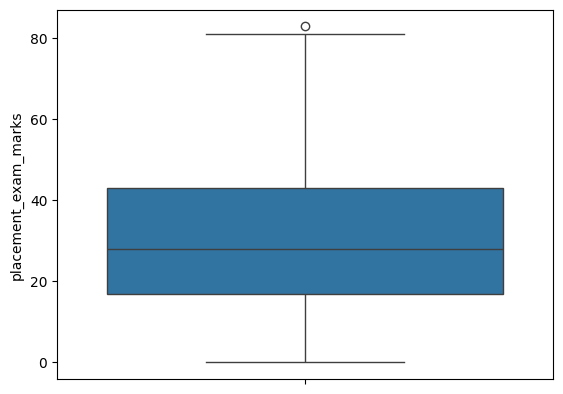

In [29]:
sns.boxplot(new_df["placement_exam_marks"])

In [31]:
new_df.to_csv("./placement_new.csv")

### Comparing

<Axes: ylabel='placement_exam_marks'>

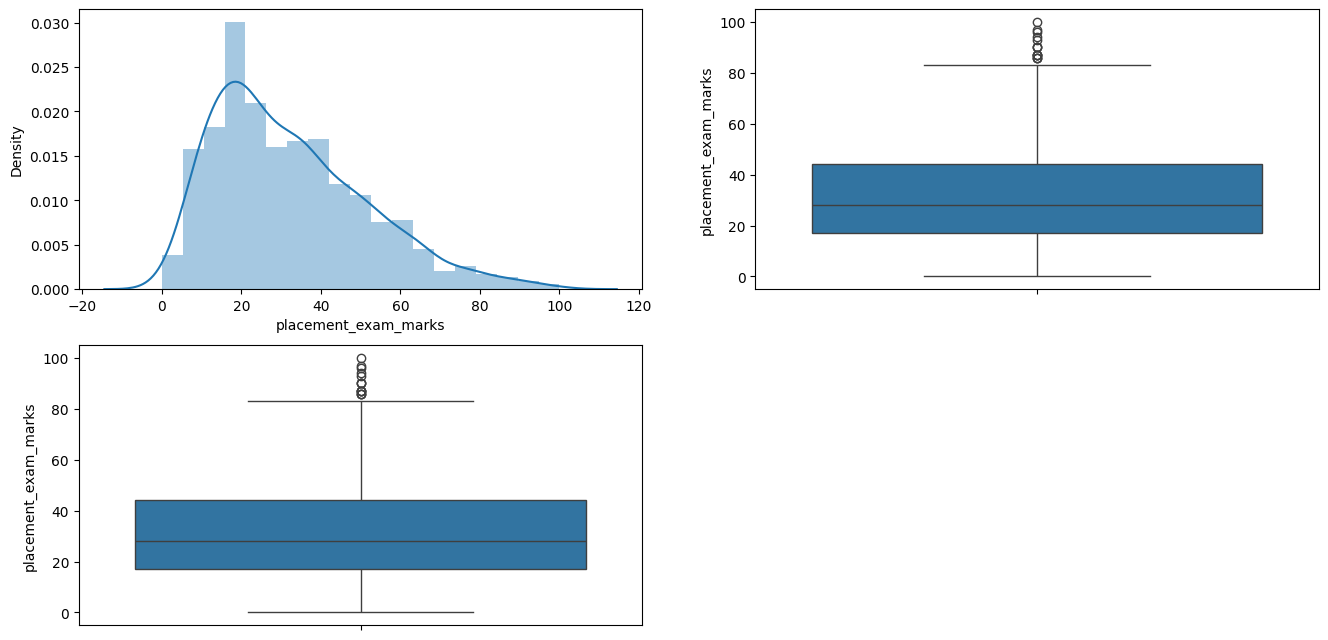

In [33]:
plt.figure(figsize=(16, 8))
plt.subplot(2, 2, 1)
sns.distplot(df.placement_exam_marks)

plt.subplot(2, 2, 2)
sns.boxplot(df.placement_exam_marks)

plt.subplot(2, 2, 3)
sns.boxplot(df.placement_exam_marks)